In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

In [2]:
from tensorflow.keras import layers

In [3]:
Data = r"C:\Users\LENOVO\Desktop\Structural_Damage_Detection\Concrete Crack Images for Classification"

image_size = (224,224)
batch_size = 32

train_ds , val_ds = tf.keras.utils.image_dataset_from_directory(
    Data,
    validation_split = 0.2,
    subset="both",
    seed = 1337,
    image_size=image_size,
    batch_size = batch_size,
    label_mode = "binary" # 0 = no crack , 1 = crack
)


Found 40000 files belonging to 2 classes.
Using 32000 files for training.
Using 8000 files for validation.


In [4]:
class_names = train_ds.class_names
print(class_names)

['Negative', 'Positive']


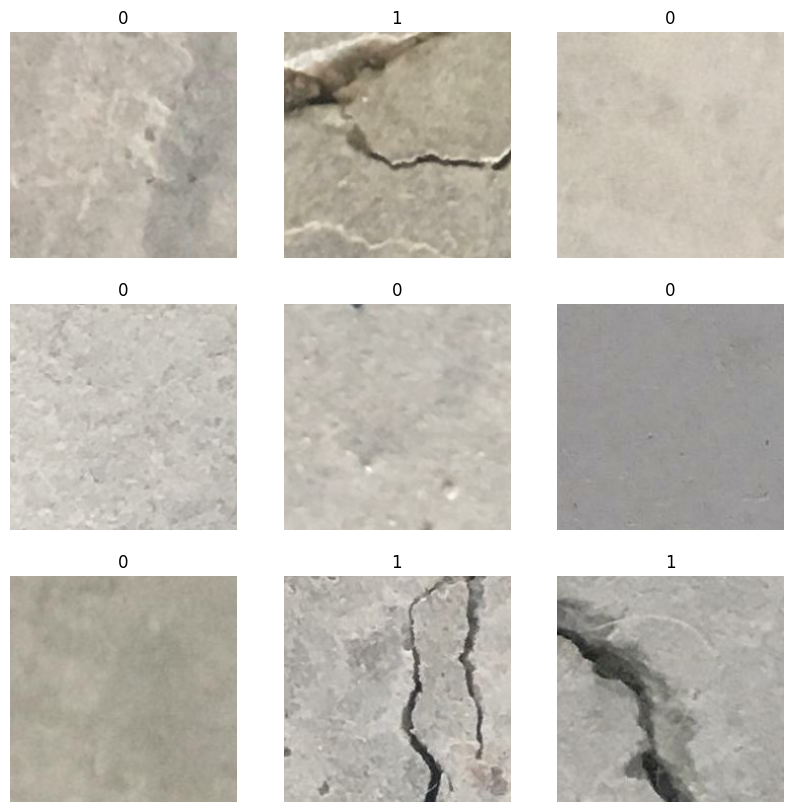

In [5]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

In [6]:
val_batches = tf.data.experimental.cardinality(val_ds)

test_dataset = val_ds.take(val_batches // 5)

val_ds = val_ds.skip(val_batches // 5)

In [7]:
autotune = tf.data.AUTOTUNE

train_dataset = train_ds.prefetch(buffer_size=autotune)
validation_dataset = val_ds.prefetch(buffer_size=autotune)
test_dataset = test_dataset.prefetch(buffer_size=autotune)

In [8]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.1),
])

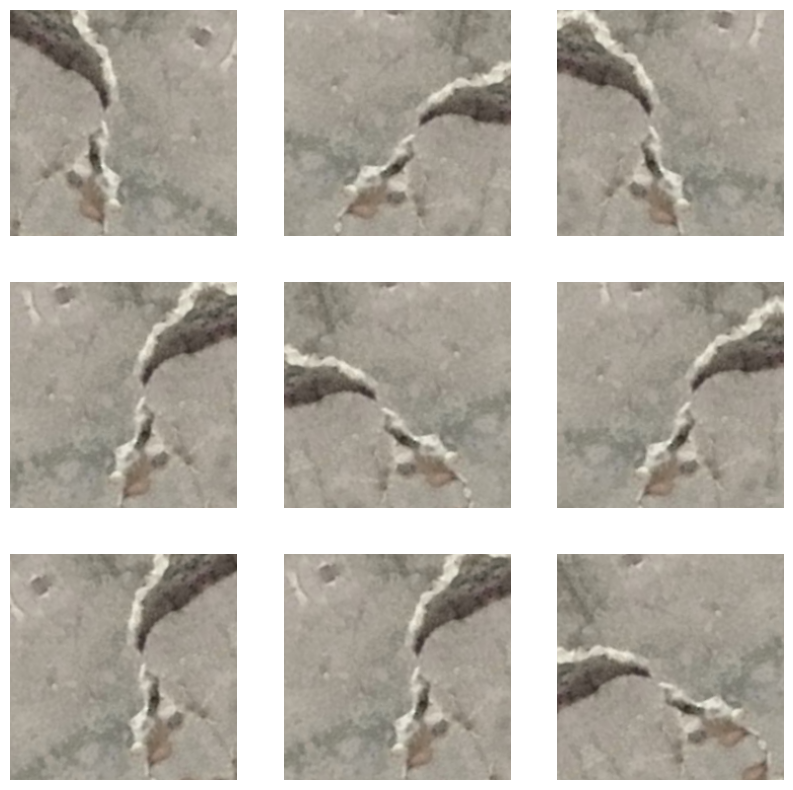

In [9]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[3]).astype("uint8"))
        plt.axis("off")


In [10]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input 

In [11]:
rescale = tf.keras.layers.Rescaling(1./127.5, offset=-1)

In [12]:
IMG_SHAPE = image_size + (3,)
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')

In [13]:
image_batch, label_batch = next(iter(train_dataset))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(32, 7, 7, 1280)


In [14]:
base_model.trainable = False

In [15]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 1280)


In [16]:
prediction_layer = tf.keras.layers.Dense(1)
prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)

(32, 1)


In [17]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)

In [18]:
base_learning_rate = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [19]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
len(model.trainable_variables)

2

In [21]:
initial_epochs = 5

loss0, accuracy0 = model.evaluate(validation_dataset)

200/200 ━━━━━━━━━━━━━━━━━━━━ 102s 498ms/step - accuracy: 0.5708 - loss: 0.6388


In [22]:
print("initial loss: {:.2f}".format(loss0))
print("initial accuracy: {:.2f}".format(accuracy0))

initial loss: 0.64
initial accuracy: 0.57


In [23]:
history = model.fit(train_dataset,
                    epochs=initial_epochs,
                    validation_data=validation_dataset)

Epoch 1/5


c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 553s 544ms/step - accuracy: 0.9686 - loss: 0.1097 - val_accuracy: 0.9962 - val_loss: 0.0261
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 594s 595ms/step - accuracy: 0.9952 - loss: 0.0211 - val_accuracy: 0.9975 - val_loss: 0.0143
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 551s 551ms/step - accuracy: 0.9966 - loss: 0.0131 - val_accuracy: 0.9975 - val_loss: 0.0107
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 509s 509ms/step - accuracy: 0.9968 - loss: 0.0109 - val_accuracy: 0.9977 - val_loss: 0.0091
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 496s 496ms/step - accuracy: 0.9975 - loss: 0.0086 - val_accuracy: 0.9981 - val_loss: 0.0077


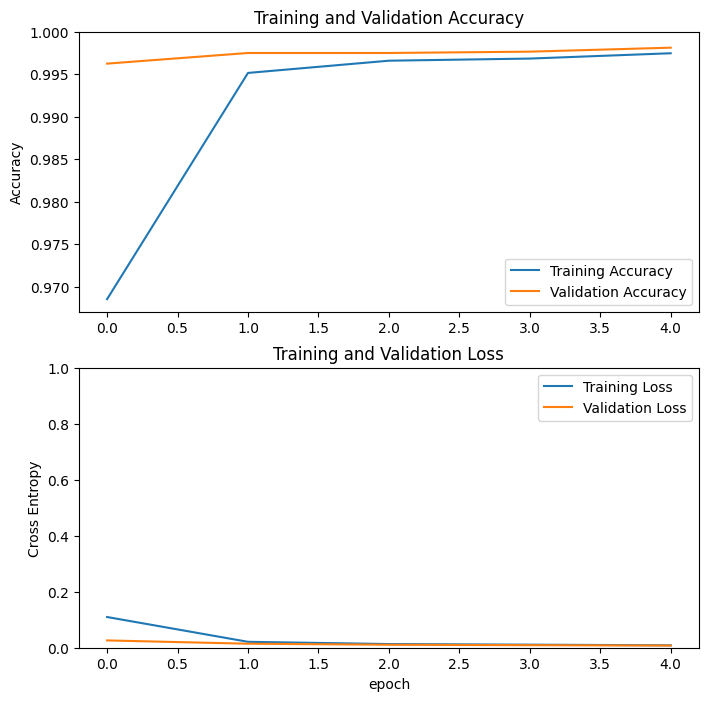

In [24]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [25]:
base_model.trainable = True

In [26]:
print("Number of layers in the base model: ", len(base_model.layers))

fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

Number of layers in the base model:  154


In [27]:
model.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer = tf.keras.optimizers.RMSprop(learning_rate=base_learning_rate/10),
              metrics=['accuracy'])

In [28]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,862,721 (7.11 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [29]:
len(model.trainable_variables)

56

In [30]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',  
    patience=3,  
    restore_best_weights=True 
)

fine_tune_epochs = 3
total_epochs =  initial_epochs + fine_tune_epochs 

history_fine = model.fit(train_dataset,
                         epochs=total_epochs,
                         initial_epoch=history.epoch[-1],
                         validation_data=validation_dataset,
                         callbacks=[early_stop])

Epoch 5/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 704s 696ms/step - accuracy: 0.9893 - loss: 0.0339 - val_accuracy: 0.9925 - val_loss: 0.0173
Epoch 6/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 712s 712ms/step - accuracy: 0.9974 - loss: 0.0084 - val_accuracy: 0.9978 - val_loss: 0.0054
Epoch 7/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 711s 711ms/step - accuracy: 0.9976 - loss: 0.0075 - val_accuracy: 0.9989 - val_loss: 0.0036
Epoch 8/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 700s 700ms/step - accuracy: 0.9986 - loss: 0.0050 - val_accuracy: 0.9991 - val_loss: 0.0033


In [31]:
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']

loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

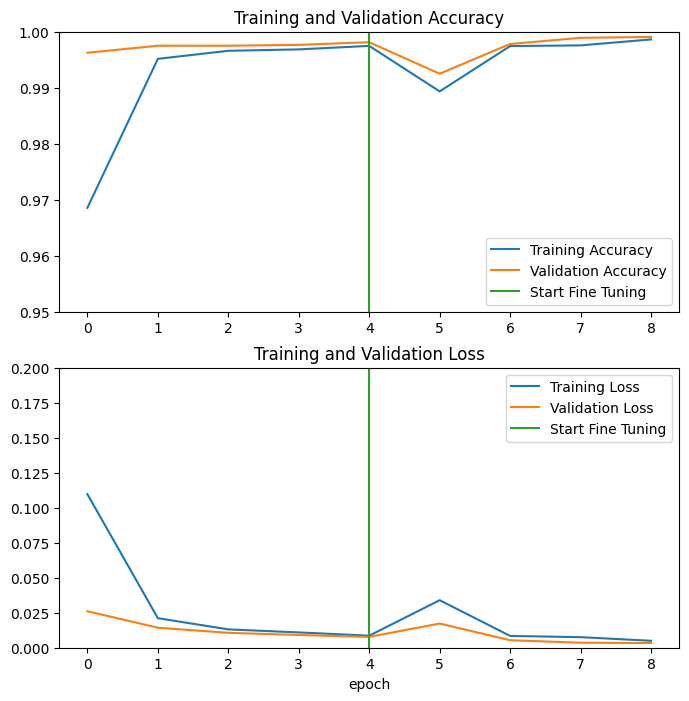

In [32]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0.95, 1])
plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 0.2])
plt.plot([initial_epochs-1,initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [33]:
loss, accuracy = model.evaluate(test_dataset)
print('Test accuracy :', accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 362ms/step - accuracy: 0.9975 - loss: 0.0151
Test accuracy : 0.9975000023841858


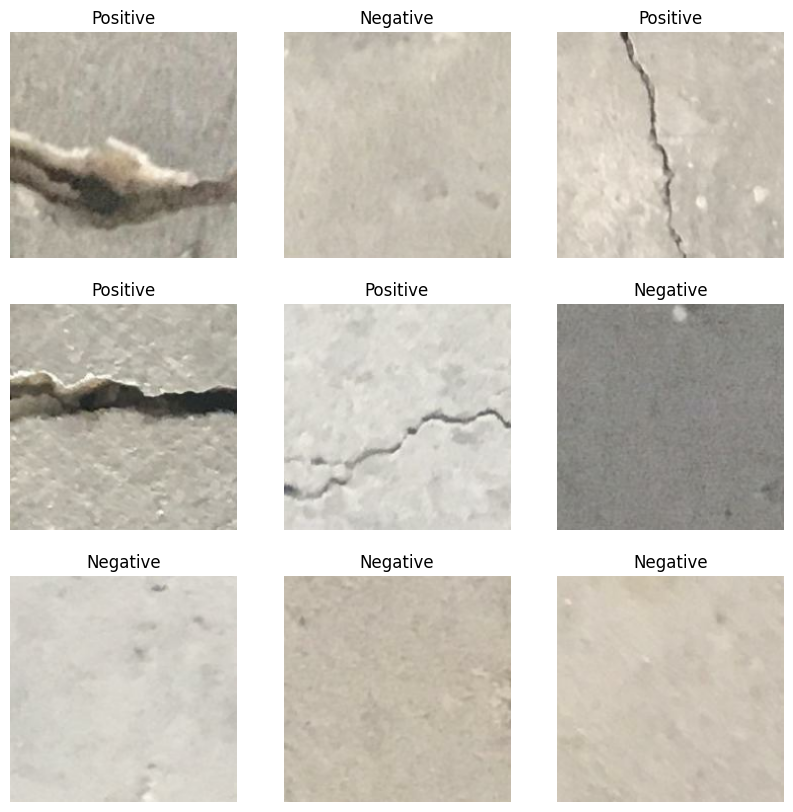

In [34]:
image_batch, label_batch = test_dataset.as_numpy_iterator().next()
predictions = model.predict_on_batch(image_batch).flatten()

predictions = tf.nn.sigmoid(predictions)
predictions = tf.where(predictions < 0.5, 0, 1)

plt.figure(figsize=(10, 10))
for i in range(9):
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(image_batch[i].astype("uint8"))
  plt.title(class_names[predictions[i]])
  plt.axis("off")

In [41]:
model.save("crack_model.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

🧠 MODELİN BEYNİNDEN GEÇENLER
Ham Matematiksel Skor (Logit) : -12.8426
Nihai Karar: ✅ SAĞLAM (NO CRACK)
Eminlik Oranı: %100.00


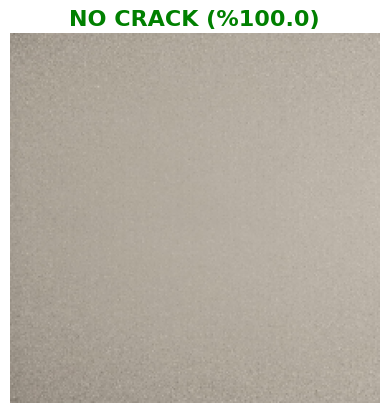

In [40]:
import tensorflow as tf
import matplotlib.pyplot as plt
resim_yolu = r"C:\Users\LENOVO\Desktop\WhatsApp Image 2026-09-03 at 15.23.12.jpeg"

def betonu_test_et(resim_yolu, egitilmiş_model):
    # 1. Resmi yükle ve modelin beklediği boyuta (224x224) getir
    img = tf.keras.utils.load_img(resim_yolu, target_size=(224, 224))
    
    # 2. Resmi matematiksel bir matrise (Array) çevir
    img_array = tf.keras.utils.img_to_array(img)
    
    # 3. Model tek bir resim değil, her zaman bir "paket (batch)" bekler.
    # Bu yüzden resmin boyutunu (224, 224, 3) formatından (1, 224, 224, 3) formatına genişletiyoruz.
    img_array = tf.expand_dims(img_array, 0)
    
    # 4. Modelden ham tahmini (Logit) al
    # Çıktı formatı örneğin [[1.245]] şeklinde bir liste içinde liste olduğu için [0][0] ile içindeki sayıyı çekiyoruz.
    ham_skor = egitilmiş_model.predict(img_array)[0][0]
    
    # 5. Ham skoru Sigmoid formülüyle 0 ile 1 arasında yüzdelik bir ihtimale çevir
    ihtimal = tf.math.sigmoid(ham_skor).numpy()
    
    # --- GÖRSELLEŞTİRME VE YAZDIRMA KISMI ---
    plt.imshow(img)
    plt.axis('off') # Resmin kenarındaki x-y eksen sayılarını gizle
    
    print("\n" + "="*30)
    print("🧠 MODELİN BEYNİNDEN GEÇENLER")
    print("="*30)
    print(f"Ham Matematiksel Skor (Logit) : {ham_skor:.4f}")
    
    # Eğer ihtimal 0.5'ten (yani %50'den) büyükse -> Sınıf 1 (Positive / Crack)
    if ihtimal > 0.5:
        eminlik = ihtimal * 100
        print(f"Nihai Karar: ⚠️ ÇATLAK VAR (CRACK)")
        print(f"Eminlik Oranı: %{eminlik:.2f}")
        plt.title(f"CRACK (%{eminlik:.1f})", color="red", fontsize=16, fontweight='bold')
        
    # Eğer ihtimal 0.5'ten küçükse -> Sınıf 0 (Negative / No Crack)
    else:
        eminlik = (1 - ihtimal) * 100 # Sağlam olduğundan ne kadar emin olduğunu bulmak için 1'den çıkarıyoruz
        print(f"Nihai Karar: ✅ SAĞLAM (NO CRACK)")
        print(f"Eminlik Oranı: %{eminlik:.2f}")
        plt.title(f"NO CRACK (%{eminlik:.1f})", color="green", fontsize=16, fontweight='bold')
        
    plt.show()

betonu_test_et(resim_yolu, model)
# --- NASIL KULLANACAKSINIZ? ---
# Sadece test etmek istediğiniz resmin yolunu ve modelinizi fonksiyona verin:
# betonu_test_et("disaridan_indirdigim_beton.jpg", model)